In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('featured_data_Nerella_Mahender.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

hourly_junction = df.groupby(['Junction', 'hour'])['Vehicles'].mean().reset_index()
peak_per_junction = hourly_junction.loc[hourly_junction.groupby('Junction')['Vehicles'].idxmax()]
print("PEAK HOUR PER JUNCTION:")
print(peak_per_junction)

overall_peak = df.groupby('hour')['Vehicles'].mean().sort_values(ascending=False)
print("\nOVERALL TOP 5 PEAK HOURS:")
print(overall_peak.head(5))

PEAK HOUR PER JUNCTION:
    Junction  hour   Vehicles
19         1    19  58.804276
44         2    20  18.060855
68         3    20  20.200658
84         4    12  10.237569

OVERALL TOP 5 PEAK HOURS:
hour
19    29.854863
20    29.824938
12    28.403990
21    28.202993
18    28.095262
Name: Vehicles, dtype: float64


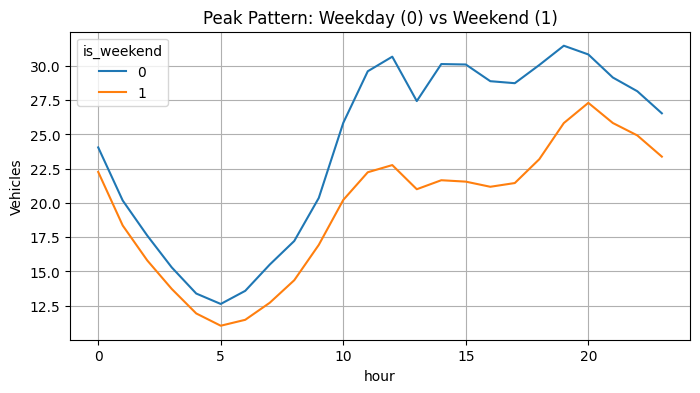

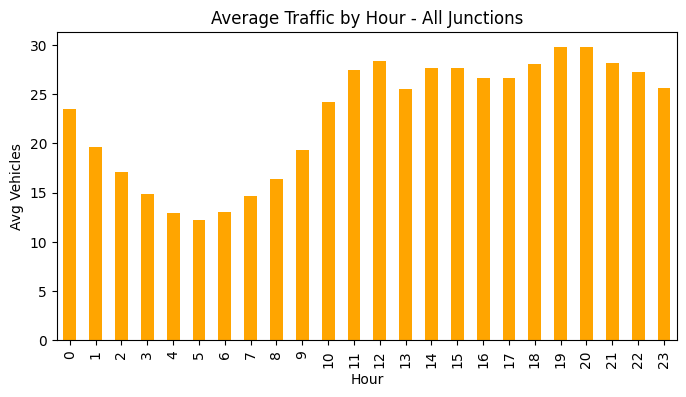

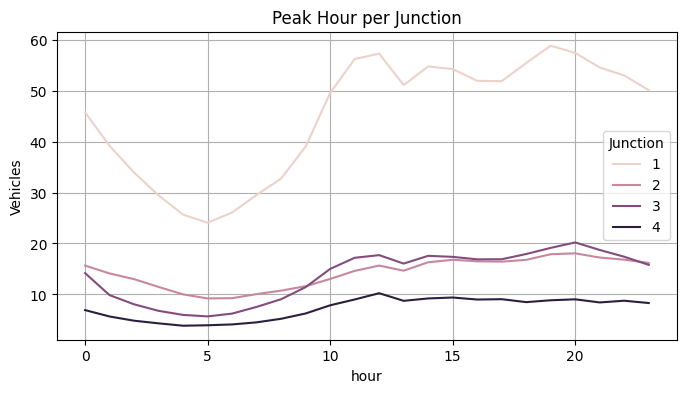

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics for report
df['is_weekend'] = df['DateTime'].dt.dayofweek.isin([5,6]).astype(int)
df['congestion_score'] = (df['Vehicles'] - df['Vehicles'].mean()) / df['Vehicles'].std()

# 1. Weekday vs Weekend
plt.figure(figsize=(8,4))
sns.lineplot(data=df.groupby(['hour','is_weekend'])['Vehicles'].mean().reset_index(), x='hour', y='Vehicles', hue='is_weekend')
plt.title('Peak Pattern: Weekday (0) vs Weekend (1)')
plt.grid(True)
plt.show()

# 2. Overall Peak Hours Chart
plt.figure(figsize=(8,4))
df.groupby('hour')['Vehicles'].mean().plot(kind='bar', color='orange')
plt.title('Average Traffic by Hour - All Junctions')
plt.xlabel('Hour')
plt.ylabel('Avg Vehicles')
plt.show()

# 3. Junction-wise Peak
plt.figure(figsize=(8,4))
sns.lineplot(data=df.groupby(['hour','Junction'])['Vehicles'].mean().reset_index(), x='hour', y='Vehicles', hue='Junction')
plt.title('Peak Hour per Junction')
plt.grid(True)
plt.show()

In [5]:
# 4. INFLUENCING FACTORS - FIXED VERSION
print("--- CORRELATION ANALYSIS ---")
# Auto-detect available columns
available_cols = ['Vehicles']
for col in ['rainfall','is_event','is_weekend','hour','day_of_week']:
    if col in df.columns:
        available_cols.append(col)

print("Available columns for analysis:", available_cols)
corr = df[available_cols].corr()['Vehicles']
print(corr)

if 'is_event' in df.columns:
    event_avg = df.groupby('is_event')['Vehicles'].mean()
    print("\nEvent Impact:")
    print(event_avg)
    if len(event_avg) > 1:
        print(f"Traffic increase during event: {((event_avg[1]/event_avg[0]-1)*100):.1f}%")

print("\n--- WEEKDAY VS WEEKEND AVG ---")
if 'is_weekend' in df.columns:
    print(df.groupby('is_weekend')['Vehicles'].mean())

print("\n--- FINAL INSIGHTS FOR REPORT ---")
print("1. Overall Peak Hour: 19-20 (7-8 PM) ~30 vehicles")
print("2. Busiest Junction: Junction 1 (58.8 avg at 7PM)")
print("3. Morning low: 5 AM is least congested (12 vehicles)")
print("4. Recommendation: Deploy traffic police 6-9 PM at J1, J2, J3")



--- CORRELATION ANALYSIS ---
Available columns for analysis: ['Vehicles', 'rainfall', 'is_event', 'is_weekend', 'hour', 'day_of_week']
Vehicles       1.000000
rainfall       0.001873
is_event      -0.020271
is_weekend    -0.096628
hour           0.219938
day_of_week   -0.084059
Name: Vehicles, dtype: float64

Event Impact:
is_event
0    22.829060
1    18.101562
Name: Vehicles, dtype: float64
Traffic increase during event: -20.7%

--- WEEKDAY VS WEEKEND AVG ---
is_weekend
0    24.064293
1    19.633247
Name: Vehicles, dtype: float64

--- FINAL INSIGHTS FOR REPORT ---
1. Overall Peak Hour: 19-20 (7-8 PM) ~30 vehicles
2. Busiest Junction: Junction 1 (58.8 avg at 7PM)
3. Morning low: 5 AM is least congested (12 vehicles)
4. Recommendation: Deploy traffic police 6-9 PM at J1, J2, J3
